<a href="https://colab.research.google.com/github/nishu-0618/ML_projects/blob/main/end_to_end_pipeline/classification_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training pipeline with 5-fold cross-validation...
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       119
           1       0.88      0.88      0.88       121

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.88      0.88      0.88       240



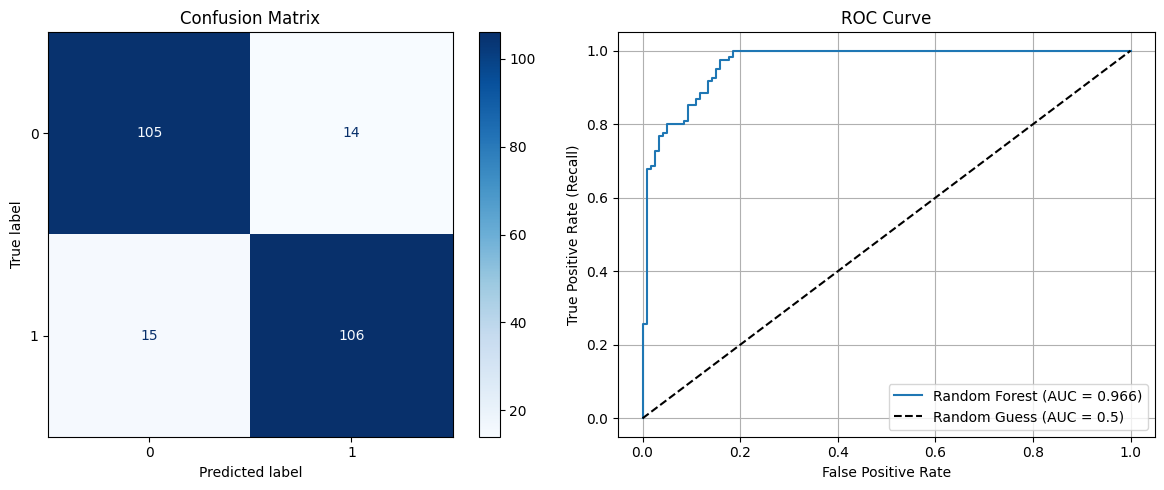

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

X, y = make_classification(
    n_samples=1200,
    n_features=8,
    n_informative=5,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Training pipeline with 5-fold cross-validation...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}\n")

y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix")

auc_score = roc_auc_score(y_test, y_probs)
fpr, tpr, _ = roc_curve(y_test, y_probs)

ax[1].plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
ax[1].plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate (Recall)")
ax[1].set_title("ROC Curve")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()